# Build matrix of interactions

In [57]:
import pandas as pd

df = pd.read_csv('protein_interactions.csv')
#df = pd.read_csv('/home/gbiuser/Documents/vitoria/usp-masters/8-docking/interactions/protein_interactions.csv')    
print(df.shape)
print(df.columns)

(3652, 47)
Index(['protein', 'ligand', 'binding_site', 'interaction_type', 'resnr',
       'restype', 'reschain', 'resnr_lig', 'restype_lig', 'reschain_lig',
       'dist', 'ligcoo', 'protcoo', 'sidechain', 'dist_h_a', 'dist_d_a',
       'don_angle', 'protisdon', 'donoridx', 'donortype', 'acceptoridx',
       'acceptortype', 'dist_a_w', 'dist_d_w', 'water_angle', 'water_idx',
       'acc_angle', 'protispos', 'lig_group', 'lig_idx_list', 'cent_dist',
       'angle', 'offset', 'type', 'protcharged', 'metalcoo', 'targetcoo',
       'metal_idx', 'metal_type', 'target_idx', 'target_type', 'coordination',
       'location', 'rms', 'geometry', 'complexnum', 'residue_id'],
      dtype='object')


In [58]:
df["protein"].value_counts()

protein
PDE4D_dimer        857
PDE4D_catalytic    635
PDE4D_monomer      582
PDE4B_monomer      534
PDE4B_catalytic    532
PDE4B_dimer        512
Name: count, dtype: int64

## Conserved residues across all complexes

In [59]:
# create df disconsindering ions
df_lig = df[df["binding_site"].str.startswith("UNL:")].copy()


In [8]:
# aggregate number of interactions based on number of proteins and ligands 
conserved = (
    df_lig.groupby("residue_id")
            .agg(
                n_proteins=("protein", "nunique"),
                n_ligands=("ligand", "nunique"),
                n_complexes=("protein", lambda x: len(set(zip(x, df.loc[x.index, "ligand"])))),
            )         
            .reset_index()
)

In [9]:
conserved.sort_values("n_complexes", ascending=False).head(20)

,residue_id,n_proteins,n_ligands,n_complexes
39,PHE618:A,3,20,53
41,PHE674:A,3,20,52
28,ILE638:A,3,19,46
55,TYR405:A,3,20,46
27,ILE582:A,3,20,42
13,GLN671:A,3,18,41
4,ASN623:A,3,18,40
56,TYR461:A,3,18,35
18,HIS406:A,3,18,34
38,PHE586:A,3,19,33


In [10]:
conserved.sort_values("n_proteins", ascending=False).head(20)

,residue_id,n_proteins,n_ligands,n_complexes
3,ASN567:A,3,16,30
4,ASN623:A,3,18,40
14,GLU476:A,3,3,5
11,GLN615:A,3,17,28
13,GLN671:A,3,18,41
8,ASP620:A,3,12,19
7,ASP564:A,3,16,23
28,ILE638:A,3,19,46
21,HIS450:A,3,9,10
22,HIS462:A,3,16,31


### Conserved only in PDE4B

In [60]:
PDE4B_subset = [
    "PDE4B_dimer",
    "PDE4B_monomer",
    "PDE4B_catalytic"
]

df_subset = df[
    df["protein"].isin(PDE4B_subset)
].copy()

conserved_PDE4B = (
    df_subset.groupby("residue_id")
             .agg(
                 n_proteins=("protein", "nunique"),
                 n_ligands=("ligand", "nunique"),
                 n_complexes=("protein", lambda x: len(set(zip(x, df_subset.loc[x.index, "ligand"]))))
             )
             .reset_index()
             .sort_values(
                 ["n_proteins", "n_ligands"],
                 ascending=False
             )
)



In [61]:
conserved_PDE4B.head(30)

,residue_id,n_proteins,n_ligands,n_complexes
12,HIS446:A,3,20,60
17,ILE582:A,3,20,42
23,PHE618:A,3,20,53
30,TYR405:A,3,20,43
22,PHE586:A,3,19,33
10,HIS406:A,3,18,34
5,ASP564:A,3,17,24
7,GLN615:A,3,17,28
1,ASN567:A,3,16,33
20,MET519:A,3,10,13


# types analysis

In [9]:
df_lig.columns

Index(['protein', 'ligand', 'binding_site', 'interaction_type',
       'residue_number', 'residue_name', 'residue_chain', 'residue_id'],
      dtype='object')

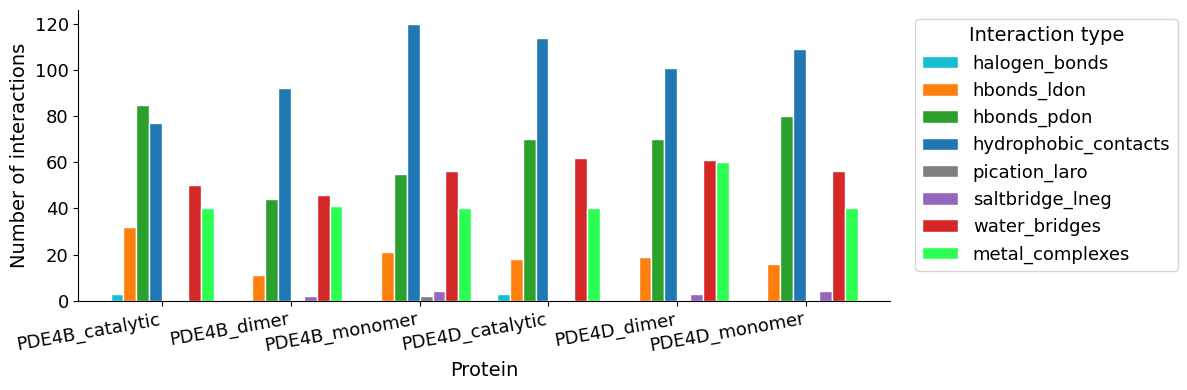

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

colors = {
    "hydrophobic_contacts": "#1f77b4",
    "hbonds_ldon": "#ff7f0e",
    "hbonds_pdon": "#2ca02c",
    "water_bridges": "#d62728",
    "saltbridge_lneg": "#9467bd",
    "saltbridge_pneg": "#8c564b",
    "pistacking": "#e377c2",
    "pication_laro": "#7f7f7f",
    "pication_paro": "#bcbd22",
    "halogen_bonds": "#17becf",
    "metal_complexes": "#2bff52",}

counts = (
    df[df["interaction_type"] != "metal_complexes"]
    .groupby(["protein", "interaction_type"])
    .size()
    .unstack(fill_value=0))

# Count unique ligand-metal complexes
metal_counts = (
    df[df["interaction_type"] == "metal_complexes"]
    [["protein", "ligand", "binding_site"]]
    .drop_duplicates()
    .groupby("protein")
    .size()
)

counts["metal_complexes"] = metal_counts
counts = counts.fillna(0)

ax = counts.plot(
    kind="bar",
    figsize=(12, 4),
    width=0.8,
    color=[colors.get(i, "#333333") for i in counts.columns],
    edgecolor="white",
    linewidth=1
)

ax.set_xlabel("Protein", fontsize=14)
ax.set_ylabel("Number of interactions", fontsize=14)

ax.tick_params(axis="both", labelsize=13)

ax.legend(
    title="Interaction type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=13,
    title_fontsize=14
)

plt.xticks(rotation=10, ha="right", fontsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [6]:
counts

interaction_type,halogen_bonds,hbonds_ldon,hbonds_pdon,hydrophobic_contacts,pication_laro,saltbridge_lneg,water_bridges,metal_complexes
protein,,,,,,,,
PDE4B_catalytic,3,32,85,77,0,0,50,40
PDE4B_dimer,0,11,44,92,0,2,46,41
PDE4B_monomer,0,21,55,120,2,4,56,40
PDE4D_catalytic,3,18,70,114,0,0,62,40
PDE4D_dimer,0,19,70,101,0,3,61,60
PDE4D_monomer,0,16,80,109,0,4,56,40


### checking different types

In [22]:
import pandas as pd

pde4b_water_bridges = df.loc[
    df["protein"].str.startswith("PDE4B")
    & df["interaction_type"].eq("water_bridges")
].copy()

pde4b_water_bridges = pde4b_water_bridges[
        ["protein", "ligand", "resnr", "restype", "reschain"]
    ].drop_duplicates().sort_values(["protein", "ligand", "resnr"])

In [16]:
pde4b_water_bridges[pde4b_water_bridges["restype"] == "HIS"]

,protein,ligand,resnr,restype,reschain
147,PDE4B_catalytic,10176710,446,HIS,A
144,PDE4B_catalytic,10176710,450,HIS,A
284,PDE4B_catalytic,10394,410,HIS,A
200,PDE4B_catalytic,689043,410,HIS,A
366,PDE4B_catalytic,m1,450,HIS,A
338,PDE4B_catalytic,m2,410,HIS,A
420,PDE4B_catalytic,m4,410,HIS,A
418,PDE4B_catalytic,m4,450,HIS,A
474,PDE4B_catalytic,m5,410,HIS,A
475,PDE4B_catalytic,m5,446,HIS,A


In [21]:
import pandas as pd

pde4b_hydrophobic_contacts = df.loc[
    df["protein"].str.startswith("PDE4B")
    & df["interaction_type"].eq("hydrophobic_contacts")
].copy()

pde4b_hydrophobic_contacts = pde4b_hydrophobic_contacts[
        ["protein", "ligand", "resnr", "restype", "reschain"]
    ].drop_duplicates().sort_values(["protein", "ligand", "resnr"])

In [18]:
pde4b_hydrophobic_contacts["restype"].value_counts()

restype
PHE    86
ILE    42
TYR    21
MET    19
HIS    10
SER     7
LEU     3
Name: count, dtype: int64

In [23]:
import pandas as pd

hbonds_pdon = df.loc[
    df["protein"].str.startswith("PDE4B")
    & df["interaction_type"].eq("hbonds_pdon")
].copy()

hbonds_pdon["restype"].value_counts()

restype
GLN    52
HIS    42
ASN    39
TYR    20
GLU    10
THR     9
SER     6
MET     4
ASP     1
TRP     1
Name: count, dtype: int64

### specific residues

In [73]:
# 582
residue_582 = df[df["resnr"].eq(582)].copy()

interaction_type_counts_582 = (
    residue_582["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)

print(f"Total interactions involving residue 582: {len(residue_582)}")
print(interaction_type_counts_582)

print(residue_582["protein"].value_counts())


Total interactions involving residue 582: 54
       interaction_type  count
0  hydrophobic_contacts     54
protein
PDE4B_monomer      23
PDE4B_dimer        17
PDE4B_catalytic    14
Name: count, dtype: int64


In [68]:
# 406
residue_406 = df[df["resnr"].eq(406)].copy()

interaction_type_counts_406 = (
    residue_406["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)

print(f"Total interactions involving residue 406: {len(residue_406)}")
print(interaction_type_counts_406)

residue_406["protein"].value_counts()


Total interactions involving residue 406: 71
       interaction_type  count
0           hbonds_pdon     40
1         water_bridges     10
2  hydrophobic_contacts      9
3           hbonds_ldon      6
4       saltbridge_lneg      4
5         pication_laro      2


protein
PDE4B_dimer        28
PDE4B_monomer      23
PDE4B_catalytic    20
Name: count, dtype: int64

In [72]:
# 618
residue_618 = df[df["resnr"].eq(618)].copy()

interaction_type_counts_618 = (
    residue_618["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)

print(f"Total interactions involving residue_618: {len(residue_618)}")
print(interaction_type_counts_618)

residue_618["protein"].value_counts()


Total interactions involving residue_618: 122
       interaction_type  count
0  hydrophobic_contacts    122


protein
PDE4B_monomer      61
PDE4B_catalytic    45
PDE4B_dimer        16
Name: count, dtype: int64

In [75]:
# 405
residue_405 = df[df["resnr"].eq(405)].copy()

interaction_type_counts_405 = (
    residue_405["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)

print(f"Total interactions involving residue 405: {len(residue_405)}")
print(interaction_type_counts_405)

residue_405["protein"].value_counts()


Total interactions involving residue 405: 69
       interaction_type  count
0  hydrophobic_contacts     26
1           hbonds_ldon     18
2           hbonds_pdon     14
3         water_bridges     11


protein
PDE4B_catalytic    30
PDE4B_monomer      20
PDE4B_dimer        19
Name: count, dtype: int64

In [ ]:
# 405
residue_405 = df[df["resnr"].eq(405)].copy()

interaction_type_counts_405 = (
    residue_405["interaction_type"]
    .value_counts()
    .rename_axis("interaction_type")
    .reset_index(name="count")
)

print(f"Total interactions involving residue 405: {len(residue_405)}")
print(interaction_type_counts_405)

residue_405["protein"].value_counts()
